# Bootstrap Paired Difference Plots

Visualises the paired bootstrap distributions for two model comparisons:
- **PPG − Demographics**: is the PPG model better than a demographics-only baseline?
- **PPG − PPG+Demographics**: what is the cost (or gain) of adding demographics to PPG features?

Loads pre-computed CI artifacts from `Experiment_Bootstrap_CI.py` (point estimates and CI bounds)  
and raw distribution CSVs from `Experiment_Bootstrap.py` (for the histograms).

Metric displayed: **R² (converted to %)**

In [32]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Notebook lives at Scripts/bp_lgbm/figures/ — go up one level to reach bp_lgbm/
sys.path.insert(0, str(Path.cwd().parent))
from local_paths import PERFORMANCE_RESULTS_PAPER

In [33]:
# ── Config ────────────────────────────────────────────────────────────────────
METRIC  = "R2"          # raw column name in the CSV
SCALE   = 100.0         # multiply R2 → percentage
ALPHA   = 0.05          # CI level used when generating artifacts (95% CI)
TARGETS = ["SBP", "DBP", "MAP"]

COMPARISONS = [
    {
        "name":    "ppg_minus_demo",
        "model_a": "ppg",
        "model_b": "demo",
        "title":   "PPG − Demographics",
    },
    {
        "name":    "ppg_minus_ppg_demographics",
        "model_a": "ppg",
        "model_b": "ppg_demo",
        "title":   "PPG − PPG+Demographics",
    },
]

BOOT_ROOT = PERFORMANCE_RESULTS_PAPER / "Bootstrap"

FIGSIZE    = (14, 4)   # width × height for a 3-panel figure
N_BINS     = 60
SAVE_FIGS  = True      # set False to only display

In [34]:
# ── Load raw per-model distributions ─────────────────────────────────────────
# Shape: (1000, n_metrics) per model per target
MODEL_KEYS = ["ppg", "demo", "ppg_demo"]

dist = {}  # dist[model_key][target] = pd.Series of METRIC values
for mk in MODEL_KEYS:
    dist[mk] = {}
    for target in TARGETS:
        path = BOOT_ROOT / mk / f"Distribution_{target}.csv"
        df   = pd.read_csv(path)
        dist[mk][target] = df[METRIC].values * SCALE
        print(f"  Loaded {mk}/{target}: {len(dist[mk][target])} resamples")

  Loaded ppg/SBP: 1000 resamples
  Loaded ppg/DBP: 1000 resamples
  Loaded ppg/MAP: 1000 resamples
  Loaded demo/SBP: 1000 resamples
  Loaded demo/DBP: 1000 resamples
  Loaded demo/MAP: 1000 resamples
  Loaded ppg_demo/SBP: 1000 resamples
  Loaded ppg_demo/DBP: 1000 resamples
  Loaded ppg_demo/MAP: 1000 resamples


In [35]:
# ── Compute paired differences ────────────────────────────────────────────────
# Same bootstrap draws → column-wise subtraction is exact pairing
paired_dist = {}  # paired_dist[comp_name][target] = array of differences

for comp in COMPARISONS:
    name = comp["name"]
    paired_dist[name] = {}
    for target in TARGETS:
        paired_dist[name][target] = dist[comp["model_a"]][target] - dist[comp["model_b"]][target]

In [36]:
# ── Load pre-computed CI artifacts ────────────────────────────────────────────
# CI CSVs are semicolon-delimited (sep=";") — distribution CSVs use commas

def load_ci_for_metric(comp_name, target, metric=METRIC, scale=SCALE):
    """Return (point_estimate, ci_lower, ci_upper) scaled by `scale`."""
    path = BOOT_ROOT / "paired" / comp_name / f"CI_{target}.csv"
    ci_df = pd.read_csv(path, sep=";")
    row   = ci_df[ci_df["metric"] == metric].iloc[0]
    return (
        float(row["point_estimate"]) * scale,
        float(row["ci_lower"])       * scale,
        float(row["ci_upper"])       * scale,
    )

# Pre-load everything
ci_data = {}   # ci_data[comp_name][target] = (point_est, lower, upper)
for comp in COMPARISONS:
    name = comp["name"]
    ci_data[name] = {}
    for target in TARGETS:
        ci_data[name][target] = load_ci_for_metric(name, target)
        pt, lo, hi = ci_data[name][target]
        print(f"  {name}/{target}: point={pt:.2f}%  95% CI [{lo:.2f}%, {hi:.2f}%]")

  ppg_minus_demo/SBP: point=30.36%  95% CI [21.75%, 38.86%]
  ppg_minus_demo/DBP: point=30.22%  95% CI [16.70%, 44.01%]
  ppg_minus_demo/MAP: point=36.88%  95% CI [24.72%, 49.03%]
  ppg_minus_ppg_demographics/SBP: point=4.83%  95% CI [0.80%, 9.14%]
  ppg_minus_ppg_demographics/DBP: point=3.68%  95% CI [-1.76%, 10.22%]
  ppg_minus_ppg_demographics/MAP: point=4.83%  95% CI [0.07%, 9.91%]


In [37]:
# ── Plotting helper ───────────────────────────────────────────────────────────

def plot_paired_figure(comp, axes):
    """
    Fill a row of 3 axes with the paired-difference distribution for each target.

    Parameters
    ----------
    comp  : dict from COMPARISONS
    axes  : list of 3 matplotlib Axes
    """
    name = comp["name"]

    for ax, target in zip(axes, TARGETS):
        values         = paired_dist[name][target]
        pt, lo, hi     = ci_data[name][target]

        # Histogram
        ax.hist(
            values,
            bins=N_BINS,
            density=True,
            color="steelblue",
            alpha=0.55,
            edgecolor="white",
            linewidth=0.4,
        )

        # KDE overlay
        kde    = gaussian_kde(values, bw_method="scott")
        x_grid = np.linspace(values.min(), values.max(), 400)
        ax.plot(x_grid, kde(x_grid), color="steelblue", linewidth=2)

        # CI shaded region
        ax.axvspan(lo, hi, alpha=0.18, color="steelblue", label=f"95% CI [{lo:.2f}%, {hi:.2f}%]")

        # Point estimate
        ax.axvline(
            pt,
            color="black",
            linewidth=2,
            linestyle="-",
            label=f"Point est. = {pt:.2f}%",
        )

        # CI boundary lines
        ax.axvline(lo, color="steelblue", linewidth=1.4, linestyle="--")
        ax.axvline(hi, color="steelblue", linewidth=1.4, linestyle="--")

        # Zero reference
        ax.axvline(
            0,
            color="red",
            linewidth=1.5,
            linestyle=":",
            label="No difference (0%)",
        )

        ax.set_title(target, fontsize=13, fontweight="bold")
        ax.set_xlabel(f"ΔR² (%)", fontsize=11)
        ax.set_ylabel("Density", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.45)
        ax.legend(fontsize=8.5, framealpha=0.9)

Saved: C:\Users\Felipe Saldarriaga\OneDrive - City, University of London\3.PhD\9. Experiments\2.LightGBM_SHAP\Performance_Results\Bootstrap\paired_ppg_minus_demo_R2.png


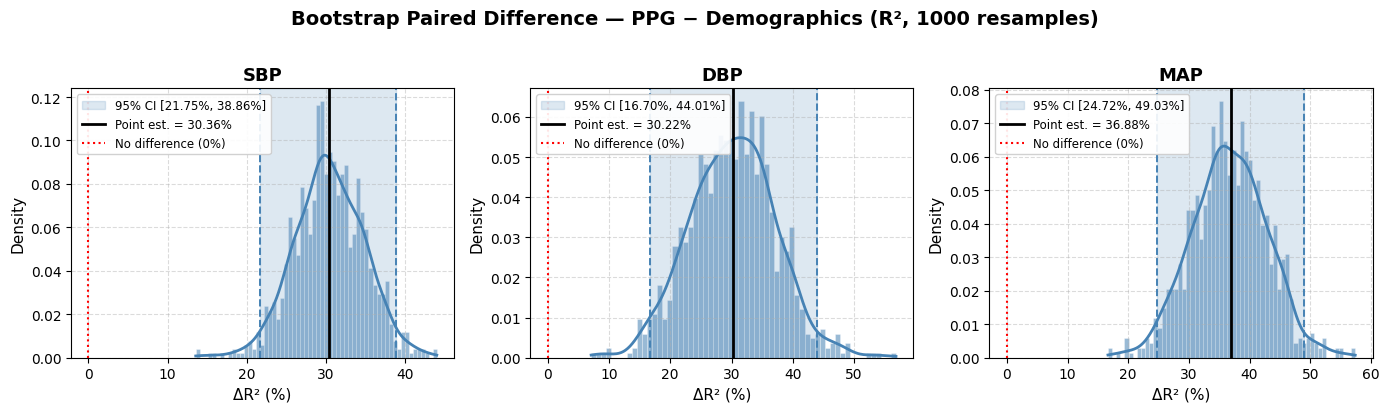

In [38]:
# ── Figure 1: PPG − Demographics ─────────────────────────────────────────────
comp1 = COMPARISONS[0]

fig1, axes1 = plt.subplots(1, 3, figsize=FIGSIZE)
fig1.suptitle(
    f"Bootstrap Paired Difference — {comp1['title']} (R², 1000 resamples)",
    fontsize=14, fontweight="bold", y=1.02,
)

plot_paired_figure(comp1, axes1)

fig1.tight_layout()

if SAVE_FIGS:
    out = BOOT_ROOT / f"paired_{comp1['name']}_R2.png"
    fig1.savefig(out, dpi=180, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()

Saved: C:\Users\Felipe Saldarriaga\OneDrive - City, University of London\3.PhD\9. Experiments\2.LightGBM_SHAP\Performance_Results\Bootstrap\paired_ppg_minus_ppg_demographics_R2.png


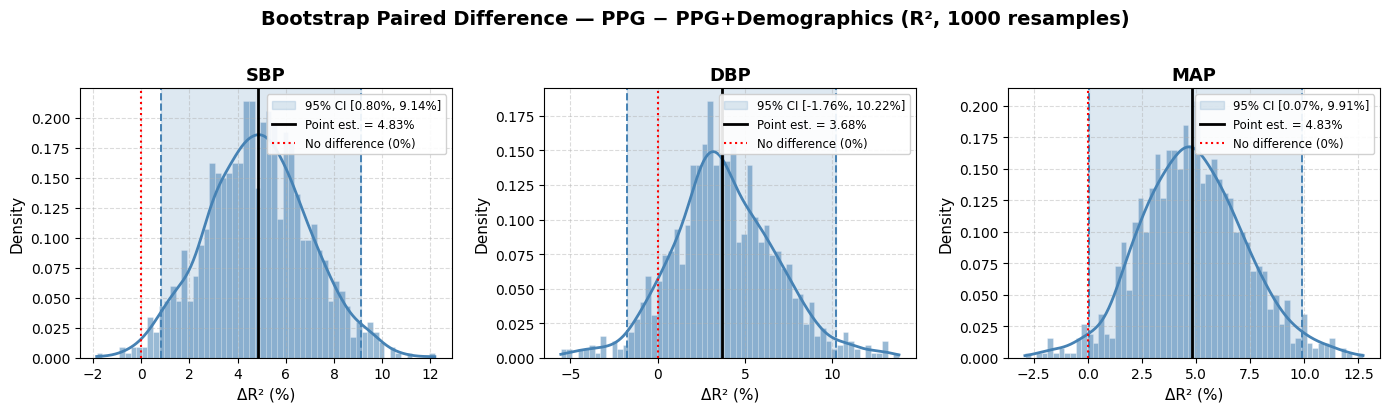

In [39]:
# ── Figure 2: PPG − PPG+Demographics ─────────────────────────────────────────
comp2 = COMPARISONS[1]

fig2, axes2 = plt.subplots(1, 3, figsize=FIGSIZE)
fig2.suptitle(
    f"Bootstrap Paired Difference — {comp2['title']} (R², 1000 resamples)",
    fontsize=14, fontweight="bold", y=1.02,
)

plot_paired_figure(comp2, axes2)

fig2.tight_layout()

if SAVE_FIGS:
    out = BOOT_ROOT / f"paired_{comp2['name']}_R2.png"
    fig2.savefig(out, dpi=180, bbox_inches="tight")
    print(f"Saved: {out}")

plt.show()